In [72]:
import pandas as pd
import os
import sys
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
sys.path.append(os.path.abspath(".."))
from scripts.utils import make_engine
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [73]:
engine = make_engine()

# read SQL query
BASE_DIR = Path.cwd().parent
sql_query = BASE_DIR / "queries" / "rfm_prep.sql"
with open(sql_query, "r") as file:
    sql_query = file.read()

# get df
df_rfm = pd.read_sql_query(sql_query, con=engine)

df_rfm.head()

,customer_id,recency,frequency,monetary
0,C0001,587,1,997.50
1,C0002,93,2,1226.30
2,C0003,374,3,1854.30
3,C0004,92,1,713.05
4,C0005,589,1,2047.25


In [74]:
# Create recency Scoring
r_bins = [-1, 60, 90, 150, 365, float('inf')]
r_labels = [5, 4, 3, 2, 1] 
df_rfm['R_Score'] = pd.cut(df_rfm['recency'], bins=r_bins, labels=r_labels).astype(int)

# Create Frequency Scoring
f_bins = [0, 1, 2, 3, 4, float('inf')]
f_labels = [1, 2, 3, 4, 5]
df_rfm["F_Score"] = pd.cut(df_rfm["frequency"], bins=f_bins, labels=f_labels).astype(int)

# Create Monetary Scoring
m_bins = [0, 1000, 2500, 4000, 5550, float('inf')]
m_labels = [1, 2, 3, 4, 5]
df_rfm["M_Score"] = pd.cut(df_rfm["monetary"], bins=m_bins, labels=f_labels).astype(int)

# find the average of F_Score and M_Score
df_rfm["FM_Score"] = df_rfm[["F_Score", "M_Score"]].mean(axis=1).round(0).astype(int)

df_rfm

,customer_id,recency,frequency,monetary,R_Score,F_Score,M_Score,FM_Score
0,C0001,587,1,997.50,1,1,1,1
1,C0002,93,2,1226.30,3,2,2,2
2,C0003,374,3,1854.30,1,3,2,2
3,C0004,92,1,713.05,3,1,1,1
4,C0005,589,1,2047.25,1,1,2,2
...,...,...,...,...,...,...,...,...
433,C0496,43,3,3373.50,5,3,3,3
434,C0497,502,1,948.10,1,1,1,1
435,C0498,362,2,2727.20,2,2,3,2
436,C0499,139,1,423.25,3,1,1,1


In [75]:
# assign segments based on R_Score and F_Score
def assign_segment(row):
    r = row["R_Score"]
    fm = row["FM_Score"]

    if r >= 3 and fm == 5:
        return "Champions"
    
    elif r >= 4 and fm == 4:
        return "Core Enthusiasts"
    
    elif r >= 3 and fm == 3:
        return "Loyal Customers"
    
    elif r == 5 and fm <= 2:
        return "Recent Samplers"
    
    elif r == 4 and fm == 2:
        return "High-Priority Win-Backs"
    
    elif r == 4 and fm == 1:
        return "About to sleep"
    
    elif r == 3 and fm >= 3:
        return "Routine Restock Reminders"

    elif r == 3 and fm <= 2:
        return "Slipping"

    elif r <= 2 and fm >= 3:
        return "Seasonal Ghosts"

    else:
        return "Lost Customers" 

    
df_rfm["Segment"] = df_rfm.apply(assign_segment, axis=1)

df_rfm["Segment"].value_counts()

Segment
Lost Customers               197
Seasonal Ghosts               64
Slipping                      34
Recent Samplers               33
High-Priority Win-Backs       28
Loyal Customers               27
Core Enthusiasts              25
Routine Restock Reminders     18
About to sleep                 9
Champions                      3
Name: count, dtype: int64

In [79]:
# pivot table
rfm_heatmap = df_rfm.pivot_table(index="FM_Score", columns="R_Score", values="customer_id", aggfunc="count")

rfm_heatmap = rfm_heatmap.iloc[::-1]
rfm_heatmap



R_Score,1,2,3,4,5
FM_Score,,,,,
5,1,2,1,1,1
4,10,21,18,12,13
3,8,22,8,10,9
2,57,66,26,28,22
1,50,24,8,9,11


<function matplotlib.pyplot.show(close=None, block=None)>

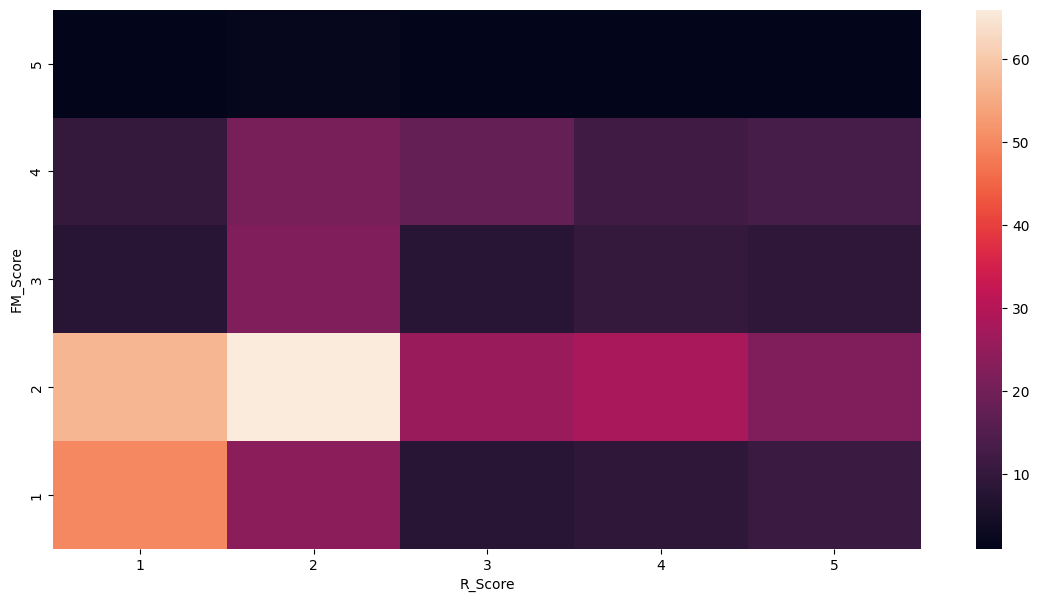

In [77]:
plt.figure(figsize=(14, 7))
sns.heatmap(data=rfm_heatmap)
plt.show